# MSE802 Quantum Computing: Assessment 2

## Task 2: Qiskit circuits

This task has two parts:

- **Part B:** A custom circuit is constructed and executed on the Quokka device, in order to demonstrate a quantum algorithm that respects the device's supported gate set.

This file only covers **Part B:**

In [1]:
'''libraries'''
import requests
from collections import Counter
from qiskit import QuantumCircuit, qasm2
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit_aer import AerSimulator
from IPython.display import display, Markdown
from qiskit.visualization import plot_histogram, plot_distribution

## Part B: A Grover Search over Four States

For the custom circuit, this notebook implements Grover's search algorithm on two qubits. Grover's algorithm is a quantum search algorithm that uses amplitude amplification in order to locate a marked item within an unstructured search space (Grover, 1996). A classical search over $N$ unsorted items requires $O(N)$ oracle queries in the worst case, whereas Grover's algorithm requires approximately $O(\sqrt{N})$ queries, which constitutes a quadratic speedup (Nielsen & Chuang, 2010). For a search space of four elements ($N = 4$), encoded in two qubits, a single Grover iteration is sufficient to amplify the probability of the marked state to unity under ideal conditions; consequently, the circuit is compact enough for the Quokka device and produces a result that can be validated directly against theory.

In this implementation the marked state is $|11\rangle$. The logical oracle is a controlled-Z (CZ) gate, which flips the sign of the $|11\rangle$ amplitude; however, the Quokka device does not support the `cz` instruction, and therefore the oracle is implemented through the equivalent decomposition $CZ = (I \otimes H)\,CX\,(I \otimes H)$, which uses only gates from the device's supported set (`h`, `x`, `cx`). This distinction between the logical algorithm and its physical implementation is maintained throughout the notebook.

The notebook follows an engineering workflow of five stages:

- **Design:** construct the Grover circuit in Qiskit.
- **Verify:** inspect the state vector before measurement.
- **Simulate:** execute the circuit on the local Aer simulator.
- **Deploy:** export the circuit to OpenQASM 2.0 and execute it on the Quokka device.
- **Validate:** compare the theoretical and the observed measurement results.

### The Three Stages of the Circuit

1. **Initialisation.** A Hadamard gate on each qubit places the register in an equal superposition of the four basis states:
$$|00\rangle \xrightarrow{H \otimes H} |s\rangle = \tfrac{1}{2}\left(|00\rangle + |01\rangle + |10\rangle + |11\rangle\right)$$
Every basis state holds an amplitude of $1/2$; hence each outcome would be measured with a probability of 25%.

2. **Oracle.** The oracle flips the sign of the marked state only:
$$|s\rangle \xrightarrow{\text{CZ}} \tfrac{1}{2}\left(|00\rangle + |01\rangle + |10\rangle - |11\rangle\right)$$
The four probabilities remain 25% at this point, because a phase is invisible to a direct measurement; the mark is stored in the sign of the amplitude rather than in its magnitude.

3. **Diffusion.** The diffusion operator $D = (H \otimes H)(X \otimes X)\,CZ\,(X \otimes X)(H \otimes H)$ reflects every amplitude about the average amplitude (Nielsen & Chuang, 2010). Because the marked amplitude is negative, the reflection amplifies it while the other three amplitudes cancel; after one iteration the register is therefore left in a state equivalent to $|11\rangle$.

```
        init        oracle (CZ on |11>)           diffusion
q0: ──[H]──░────────────■─────────────░──[H][X]───────■───────[X][H]──░──[M]
q1: ──[H]──░──[H]───────X───────[H]───░──[H][X]──[H]──X──[H]──[X][H]──░──[M]
```

**What To Expect:** On the Aer simulator the expected measurement outcome is 100% `11` under ideal simulation. On the Quokka device the measurements should be strongly concentrated on `11`; an ideal backend will also return 100%, whereas a noisy backend may exhibit small deviations due to hardware or simulator characteristics.

### B.1 Design: Build the Grover Circuit in Qiskit

The three stages are separated by barriers in order to keep the structure visible in the circuit diagram and in the exported QASM; the barrier instruction is accepted by the Quokka device and does not alter the state. Both occurrences of the logical CZ gate, one inside the oracle and one inside the diffusion operator, are written as the decomposition $H \cdot CX \cdot H$ on the target qubit.

In [2]:
qc = QuantumCircuit(2)

# Stage 1: initialisation -> equal superposition over the four basis states
qc.h([0, 1])
qc.barrier()

# Stage 2: oracle marking |11> (logical CZ, built as H.CX.H on the target)
qc.h(1)
qc.cx(0, 1)
qc.h(1)
qc.barrier()

# Stage 3: diffusion operator (inversion about the mean)
qc.h([0, 1])
qc.x([0, 1])
qc.h(1)
qc.cx(0, 1)                # logical CZ, again built as H.CX.H
qc.h(1)
qc.x([0, 1])
qc.h([0, 1])

# Capture the pre-measurement state vector before the measurement collapses it
state = Statevector.from_instruction(qc)

qc.measure_all()           # measure both qubits into a classical register

print(qc.draw(output="text"))

        ┌───┐ ░                 ░ ┌───┐┌───┐          ┌───┐┌───┐      ░ ┌─┐   
   q_0: ┤ H ├─░────────■────────░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░─┤M├───
        ├───┤ ░ ┌───┐┌─┴─┐┌───┐ ░ ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ░ └╥┘┌─┐
   q_1: ┤ H ├─░─┤ H ├┤ X ├┤ H ├─░─┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─░──╫─┤M├
        └───┘ ░ └───┘└───┘└───┘ ░ └───┘└───┘└───┘└───┘└───┘└───┘└───┘ ░  ║ └╥┘
meas: 2/═════════════════════════════════════════════════════════════════╩══╩═
                                                                         0  1 


### B.2 Verify: Inspect the State Vector (Before Measurement)

After one Grover iteration the circuit prepares a state equivalent to $|11\rangle$. Depending on the implementation, the state vector may appear as $-|11\rangle$, which differs only by a global phase and therefore produces identical measurement outcomes; the amplitudes of the other three basis states are zero up to floating-point residue.

In [3]:
print("Amplitudes :", state.data)
display(Markdown("State vector:"), state.draw(output="latex"))

Amplitudes : [ 5.55111512e-17+0.j -1.40915924e-17+0.j -1.90484157e-17+0.j
 -1.00000000e+00+0.j]


State vector:

<IPython.core.display.Latex object>

### B.3 Simulate: Run on the Local Aer Simulator (1024 Shots)

In order to verify the design before it is sent to the Quokka device, the circuit is executed on Qiskit's local Aer simulator for 1024 shots. Because the amplitude of the marked state is unity, the expected outcome is `11` for every shot under ideal simulation.

In [4]:
# 1. Setup the Aer backend
simulator = AerSimulator()

# 2. Run the simulation and get results
job = simulator.run(qc, shots=1024)
result = job.result()

# 3. Get and print the counts
counts = result.get_counts()
print("Aer Simulation counts:", counts)

Aer Simulation counts: {'11': 1024}


### B.4 Visualise the Results

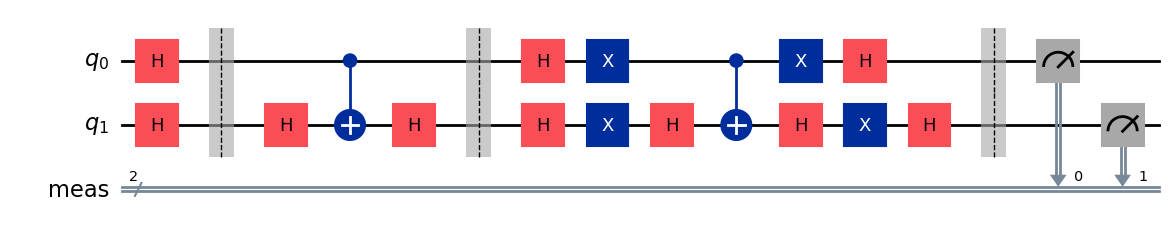

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

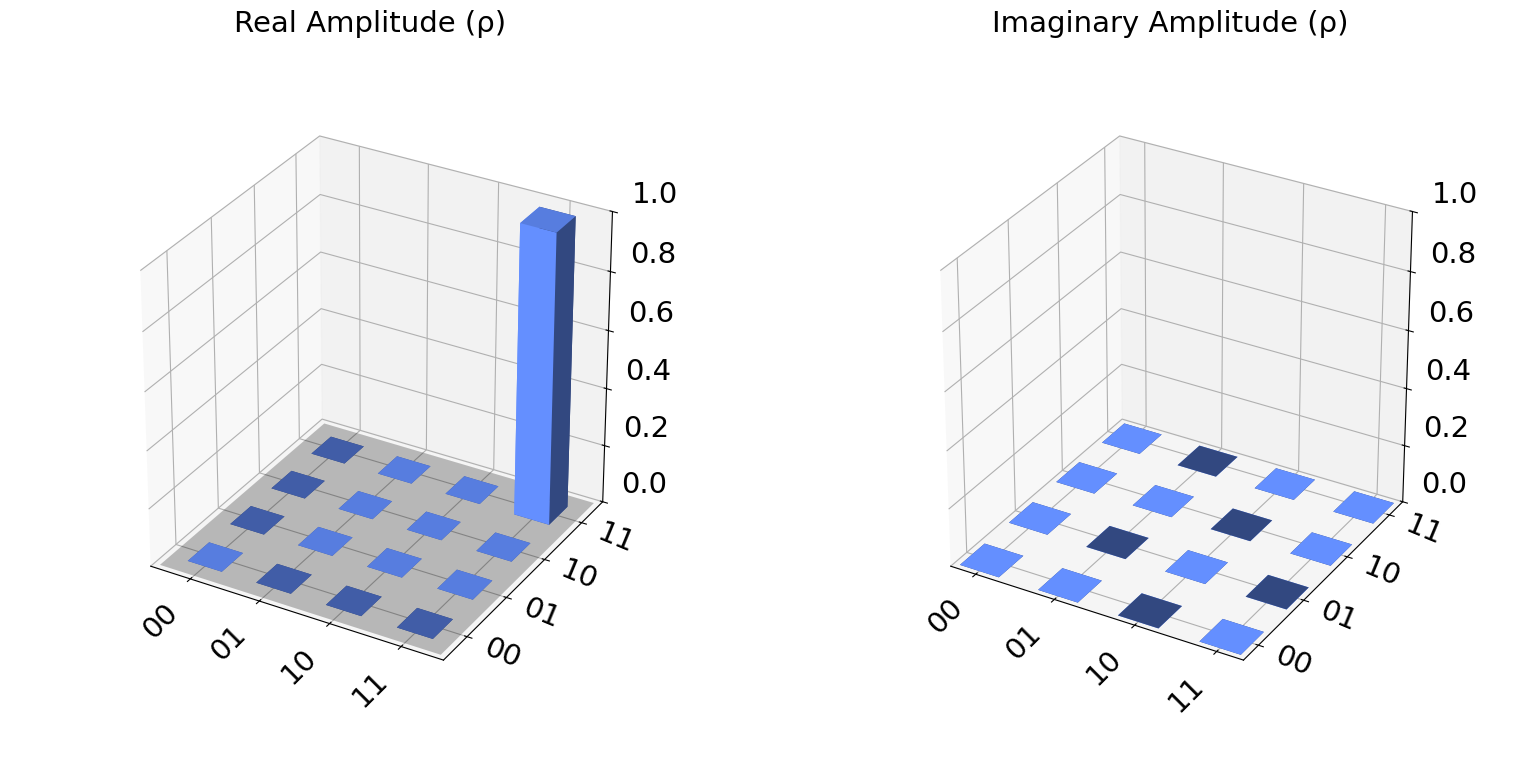

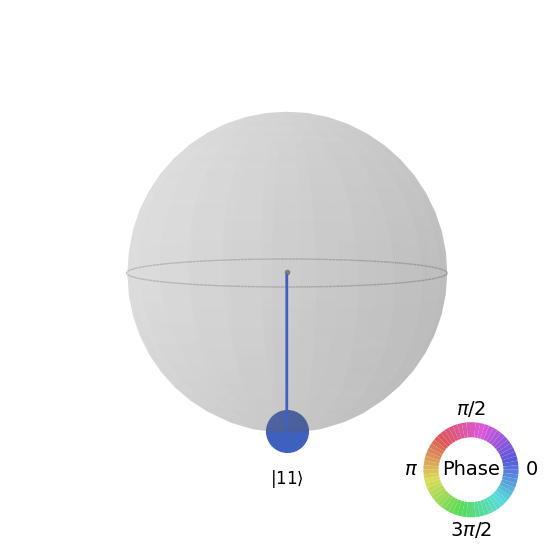

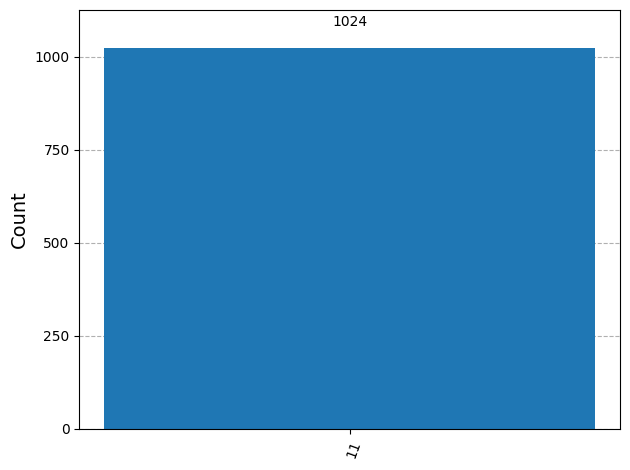

In [5]:
display(qc.draw("mpl"))                       # circuit diagram
display(state.draw("latex"))                  # state vector as a ket
display(DensityMatrix(state).draw("latex"))   # density matrix
display(state.draw("city"))                   # state-city plot
display(state.draw("qsphere"))                # Q-sphere
display(plot_histogram(counts))               # measurement counts from the Aer simulator

**Observation.** The cell above renders six complementary views of the state after one Grover iteration; each figure confirms a different property of the search, and together they connect the algebraic description of amplitude amplification to the frequencies that are actually measured.

1. The first figure is the *circuit diagram*, which reproduces the three stages as a wire diagram separated by barriers: the initialisation Hadamards, the oracle written as $H \cdot CX \cdot H$, and the diffusion operator, followed by the two final measurements. This view confirms that the circuit was constructed exactly as designed and that every instruction belongs to the Quokka supported gate set.

2. The second figure is the *state vector* in ket notation, $-|11\rangle$. Only the basis state $|11\rangle$ carries a non-zero amplitude, with a magnitude of 1, whereas the amplitudes of $|00\rangle$, $|01\rangle$ and $|10\rangle$ are exactly zero; the minus sign is a global phase, which does not affect any measurement probability.

3. The third figure is the *density matrix* $\rho = |\psi\rangle\langle\psi|$, a $4\times4$ matrix whose only non-zero entry is the diagonal element associated with $|11\rangle$, equal to 1. Because the density matrix is formed from the product of the state and its conjugate, the global phase cancels, which is why the entry appears as $+1$; furthermore, the absence of any off-diagonal coherence indicates that the register has been driven into a single definite basis state rather than a superposition (Nielsen & Chuang, 2010).

4. The fourth figure is the *state-city plot*, a three-dimensional representation of the same density matrix in which a single bar of height 1 rises at the position associated with $|11\rangle$; this provides a visual counterpart to the numerical matrix and makes the absence of any other populated element immediately apparent.

5. The fifth figure is the *Q-sphere*, on which a single node appears at $|11\rangle$ with a probability of 1; in contrast with the Bell states of Task 1 and Part A, where two nodes shared the probability equally, the search has concentrated the entire probability on the marked state.

6. The sixth figure is the *measurement histogram*, which displays the empirical counts obtained from the 1024-shot simulation: every shot returned `11`. This histogram links the theory to the experiment: according to the Born rule, the probability of an outcome equals the squared magnitude of its amplitude, so $\left|-1\right|^2 = 1$ predicts the observed frequency of 100% (Nielsen & Chuang, 2010).

Overall, a single Grover iteration raised the probability of the marked state from 25%, its value in the initial equal superposition, to 100%; the algorithm therefore located the marked item with one query of the oracle, whereas a classical search over four unsorted items requires on average more than two queries.

### B.5 Deploy: Run on the Quokka Quantum Device

The Quokka device does not accept a Qiskit circuit object directly; therefore, the circuit is exported to OpenQASM 2.0 text, saved as the required QASM script, and sent to the device's HTTP API through a `POST` request. The exported script contains only the instructions `h`, `x`, `cx`, `barrier` and `measure`, all of which belong to the device's supported set; hence no further transpilation is necessary.

### Export the Qiskit Circuit to Clean QASM

In [6]:
# Convert the Qiskit circuit to an OpenQASM 2.0 string
qasm_string = qasm2.dumps(qc)
print("Qiskit QASM 2.0:\n", qasm_string)

# Write the string to a text file (the QASM script deliverable)
with open("Task-2_Grover_qiskit.qasm", "w") as file:
    file.write(qasm_string)

print("File saved successfully as 'Task-2_Grover_qiskit.qasm'!")

Qiskit QASM 2.0:
 OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg meas[2];
h q[0];
h q[1];
barrier q[0],q[1];
h q[1];
cx q[0],q[1];
h q[1];
barrier q[0],q[1];
h q[0];
h q[1];
x q[0];
x q[1];
h q[1];
cx q[0],q[1];
h q[1];
x q[0];
x q[1];
h q[0];
h q[1];
barrier q[0],q[1];
measure q[0] -> meas[0];
measure q[1] -> meas[1];
File saved successfully as 'Task-2_Grover_qiskit.qasm'!


### Import the QASM Back into Qiskit

OPENQASM 2.0;
qreg q[2];
creg meas[2];
h q[0];
h q[1];
barrier q[0],q[1];
h q[1];
cx q[0],q[1];
h q[1];
barrier q[0],q[1];
h q[0];
h q[1];
x q[0];
x q[1];
h q[1];
cx q[0],q[1];
h q[1];
x q[0];
x q[1];
h q[0];
h q[1];
barrier q[0],q[1];
measure q[0] -> meas[0];
measure q[1] -> meas[1];


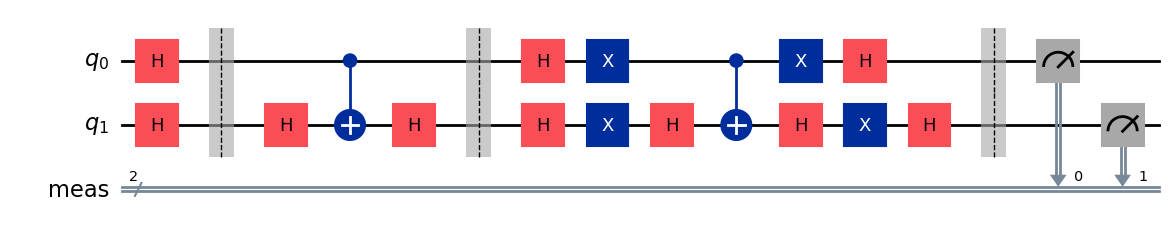

In [7]:
# Load the saved QASM back into a Qiskit circuit
circuitS = qasm2.load("Task-2_Grover_qiskit.qasm")

# Rebuild the QASM text and drop the `include "qelib1.inc";` line, which Quokka
# does not ship; a string match is safer than slicing by character position.
code = "\n".join(line for line in qasm2.dumps(circuitS).splitlines()
                 if 'include "qelib1.inc";' not in line)

print(code)
display(circuitS.draw("mpl"))

### Run on the Quokka Device

In [8]:
req_str_qasm = "http://quokka5.quokkacomputing.com/qsim/qasm"

data = {
    'script': code,
    'count': 1024
}

try:
    response = requests.post(req_str_qasm, json=data)

    # Catch non-200 responses before trying to parse JSON
    if response.status_code != 200:
        print(f"Server Error {response.status_code}: Server returned non-JSON data.")
        print("Response Snippet:", response.text[:200])
    else:
        results = response.json()
        print("Execution Results:", results)

    # Extract the raw per-shot bit-lists, ordered [meas[0], meas[1]]
    raw_shots = results['result']['meas']

    # Reverse each shot to match Qiskit's little-endian convention, then join
    # into a bitstring such as "11".
    string_shots = ["".join(map(str, shot[::-1])) for shot in raw_shots]

    # Aggregate the shots into a dictionary of counts
    quokka_counts = dict(Counter(string_shots))

    print("Quokka device counts:", quokka_counts)

except Exception as e:
    print("Error communicating with Quokka:", e)

Execution Results: {'error': 'no error', 'error_code': 0, 'result': {'meas': [[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1

### B.6 Validate: Compare the Simulator and the Device

The validation compares the two execution paths at more than the level of the final histograms, because the simulator and the device expose different information:

| Aspect | Aer Simulator | Quokka |
|---------|---------------|---------|
| State vector | Available (ideal quantum state) | Not directly observable |
| Measurements | Ideal probability distribution | Experimental probability distribution |
| Execution | Local simulation | Remote quantum platform |

On the simulator the full state vector is available, and the prediction of 100% `11` can be read directly from the amplitudes; on the device only measurement statistics are returned, and the underlying state must be inferred from the observed distribution. The plot below normalises each dataset to probabilities, so that the two runs compare fairly.

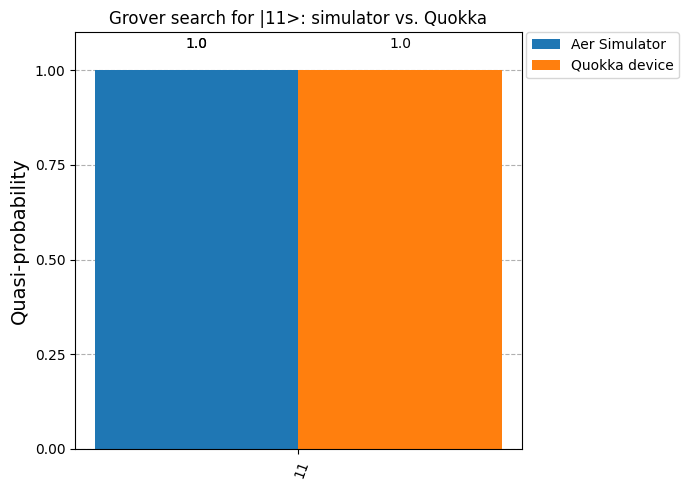

In [9]:
# plot_distribution normalises each dataset to probabilities, so the two
# 1024-shot runs compare fairly; it draws the grouped bars and the legend.
plot_distribution([counts, quokka_counts],
                  legend=["Aer Simulator", "Quokka device"],
                  title="Grover search for |11>: simulator vs. Quokka")

### B.7 Analysis

The Grover circuit was designed in Qiskit, verified through its state vector, simulated on the local Aer simulator, deployed to the Quokka device as an OpenQASM 2.0 script, and validated against the theoretical prediction. On the simulator every one of the 1024 shots returned `11`, which agrees exactly with the theoretical amplitude of unity for the marked state after one iteration; the Quokka device returned the same outcome for every shot, and consequently the observed distributions match the prediction on both platforms.

The result also illustrates the source of the quantum advantage at the smallest useful scale. A classical search over four unsorted items requires on average more than two queries of the oracle, whereas the Grover circuit located the marked item with a single oracle query; this is the quadratic speedup described by Grover (1996). It is also worth noting that the mark itself is never visible in the probabilities immediately after the oracle, since a phase flip does not change any measurement outcome; it is the diffusion operator that converts the hidden phase into a measurable amplitude, which is why both stages are necessary (Nielsen & Chuang, 2010).

A genuinely noisy physical processor would normally distribute a small number of counts across the unmarked outcomes `00`, `01` and `10`; however, the Quokka results match those of the ideal simulator, which suggests that the device behaves as an emulated, noise-free quantum processor, as was also observed in Part A. Although the device returns its bit-lists in classical-register order, which is reversed relative to Qiskit's little-endian labels and is therefore corrected before the counts are aggregated, the comparison confirms that the deployed QASM script reproduces the designed circuit exactly.

## References

Grover, L. K. (1996). A fast quantum mechanical algorithm for database search. In *Proceedings of the twenty-eighth annual ACM symposium on theory of computing* (pp. 212–219). Association for Computing Machinery. https://doi.org/10.1145/237866.237891

Nielsen, M. A., & Chuang, I. L. (2010). *Quantum computation and quantum information* (10th anniversary ed.). Cambridge University Press.

Qiskit Contributors. (n.d.). *Qiskit: An open-source framework for quantum computing* (Version 2.4.0) [Computer software]. IBM Quantum. Retrieved July 24, 2026, from https://www.ibm.com/quantum/qiskit

Quokka Computing. (n.d.). *Quokka quantum computer* [Apparatus]. Retrieved July 24, 2026, from https://www.quokkacomputing.com